<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week5/DATA_201_Week5A_Activity_Resampling_Median_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTRUCTIONS:   For each section below, put the code cells in the correct order to estimate the confidence interval of a median using

Variation: Analysis repeated to estimate confidence interval for median, rather than the mean.

Compare results using small sample and sample of 10% of the population.


In [72]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


#Section 1:  Data Cleaning/Prep

In [73]:
# tab-separated data into pandas data frame. the data is Chipotle orders
orders = pd.read_table('http://bit.ly/chiporders')

In [74]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            4622 non-null   int64 
 1   quantity            4622 non-null   int64 
 2   item_name           4622 non-null   object
 3   choice_description  3376 non-null   object
 4   item_price          4622 non-null   object
dtypes: int64(2), object(3)
memory usage: 180.7+ KB


In [75]:
orders.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [76]:
orders.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


In [77]:
orig_item_price = orders['item_price']

In [78]:
orig_item_price.head()

,item_price
0,$2.39
1,$3.39
2,$3.39
3,$2.39
4,$16.98


In [79]:
orig_item_price_str = orig_item_price.str.replace('$', '')

In [80]:
orig_item_price_str.head()

,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98


In [81]:
orig_item_price_float = orig_item_price_str.astype(float)

In [82]:
orig_item_price_float.head()

,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98


In [83]:
population = orig_item_price_float.dropna()

In [84]:
population.describe()

,item_price
count,4622.000000
mean,7.464336
std,4.245557
min,1.090000
25%,3.390000
50%,8.750000
75%,9.250000
max,44.250000


#Section 2:  Bootstrap simulation for confidence interval

Population Mean: 7.46
Population Std: 4.25
Population Median: 8.75


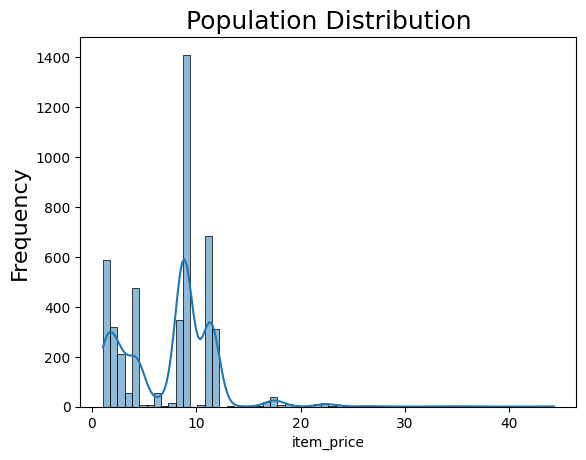

In [85]:
population_n = len(population)
mean = np.mean(population)
std = np.std(population)
median = np.median(population)

sns.histplot(population, kde=True, label='Population')
plt.title('Population Distribution', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Population Mean: {np.mean(population):.3}')
print(f'Population Std: {np.std(population):.3}')
print(f'Population Median: {np.median(population):.3}')

Sample Mean: 7.46
Sample Std: 4.86
Sample Median: 8.49


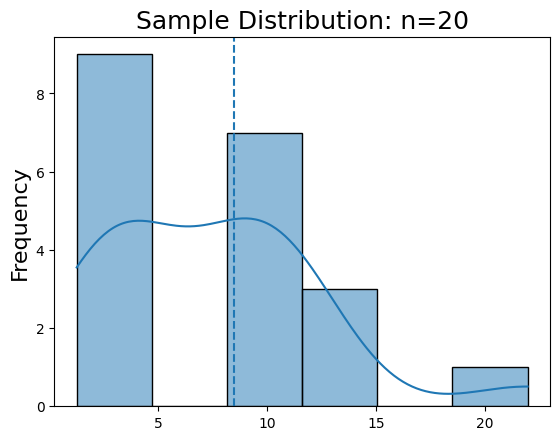

In [86]:
sample_n = 20
#sample_n = int(population_n*.10)
sample = np.random.choice(population, size=sample_n, replace=False)

sns.histplot(sample, kde=True, label='Single Sample')
plt.axvline(x=np.median(sample), ymin=0, ymax=1, linestyle='--')
plt.title(f'Sample Distribution: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Sample Mean: {np.mean(sample):.3}')
print(f'Sample Std: {np.std(sample):.3}')
print(f'Sample Median: {np.median(sample):.3}')

Bootstrapped Median: 8.49


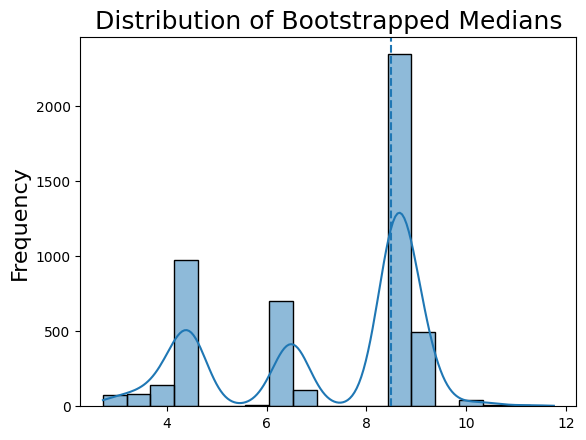

In [87]:
n_bootstrap = 5000

bootstrap_medians = []
for b in range(n_bootstrap):
    boot_sample = np.random.choice(sample, size=sample_n, replace=True)
    bootstrap_medians.append(np.median(boot_sample))

bootstrap_medians = np.array(bootstrap_medians)

sns.histplot(bootstrap_medians, kde=True, label='Bootstrap')
plt.axvline(x=np.median(bootstrap_medians), ymin=0, ymax=1, linestyle='--')
plt.title('Distribution of Bootstrapped Medians', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Bootstrapped Median: {np.median(bootstrap_medians):.3}')


Bootstrapped Median: 7.21
95% Confidence Intervals: [3.42, 9.25]


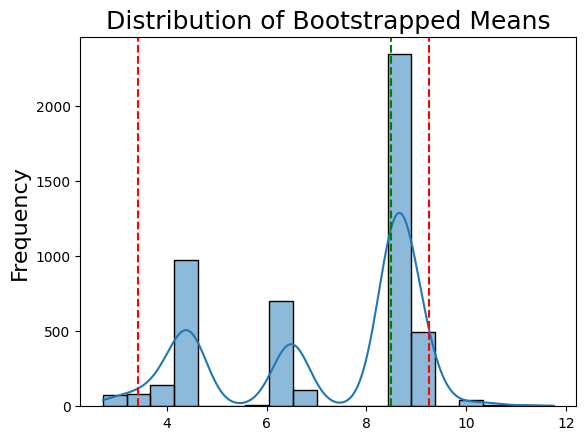

In [88]:

sns.histplot(bootstrap_medians, kde=True, label='Bootstrap')
plt.axvline(x=np.median(bootstrap_medians), ymin=0, ymax=1, color='green', linestyle='--')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

lower_bound = np.percentile(bootstrap_medians, 2.5)
upper_bound = np.percentile(bootstrap_medians, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')

print(f'Bootstrapped Median: {np.mean(bootstrap_medians):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')